In [1]:
using Oscar
using LinearAlgebra
using HomotopyContinuation
using Plots

# PRE: V is a set of points in R^2 whose convex hull defines the polygon P.
# POST: Returns the area of P = conv(V).
function areaofpolytope(V)
    P = convex_hull(QQ,V)
    return volume(P)
end

  ___   ___   ___    _    ____
 / _ \ / __\ / __\  / \  |  _ \  | Combining and extending ANTIC, GAP,
| |_| |\__ \| |__  / ^ \ |  ´ /  | Polymake and Singular
 \___/ \___/ \___//_/ \_\|_|\_\  | Type "?Oscar" for more information
o--------o-----o-----o--------o  | Documentation: https://docs.oscar-system.org
  S Y M B O L I C   T O O L S    | Version 1.7.2


areaofpolytope (generic function with 1 method)

In [2]:
# PRE: v is a point in R^2, and a, b, c are coefficients defining the line
#      H = {(x,y) : ax + by + c = 0}.
# POST: Returns the value of the hyperplane equation evaluated at v, i.e.,
#       (a,b,c) · (v₁,v₂,-1) = a*v₁ + b*v₂ - c.
function inner_product(v,a,b,c)
    v_lift = [v[1], v[2], QQ(-1)]
    s = dot([a,b,c],v_lift)
    return s
end
    

inner_product (generic function with 1 method)

In [3]:
# PRE: V is a set of vertices defining a polygon in R^2, and (a,b,c) defines
#      the line H = {(x,y) : ax + by  = c}.
# POST: Returns the sign of the evaluation of the line equation at each vertex
#       of V, classifying each vertex as lying on one side of H or on H itself.
    pos = Int[]
    for v in V
        s = inner_product(v,a,b,c)
        push!(pos, sign(s))
    end
    return pos
end

posvertices (generic function with 1 method)

In [4]:
# PRE: V is a collection of vertices in R^2 defining a polygon.
# POST: Returns the points embedded in R^3 by mapping each vertex
#       v = (x,y) to (x,y,-1).
function vertex_embed(V)
    embedding = Vector{Vector{QQFieldElem}}()
    for v in V
        v_lift = [v[1], v[2], QQ(-1)]
        push!(embedding,v_lift)
    end
    return embedding
end

vertex_embed (generic function with 1 method)

In [5]:
# PRE: V is a collection of vertices in R^2 defining a polygon, and a, b, c are
#      coefficients defining the line H = {(x,y) : ax + by - c = 0}.
# POST: Returns a vector containing the edges of the polygon that are intersected
#       by the line H.
function hyperplane_intersectedge(V,a,b,c)
	P = convex_hull(QQ,V)
	cut = []
	for e in faces(P,1)
		s = [inner_product(v,a,b,c) for v in vertices(e)]
		if prod(s) < 0
           		push!(cut, e)
        		end
	end
	return cut #Chiara: this now outputs two edges instead of just the indices of the corresponding vertices
end

hyperplane_intersectedge (generic function with 1 method)

In [6]:
# PRE: V is a collection of vertices in R^2 defining a polygon, and a, b, c are
#      coefficients defining the line H = {(x,y) : ax + by - c = 0}.
# POST: Returns the exact intersection points between H and the edges
#       of the polygon defined by the convex hull of V.
function hyperplane_intersectpoints(V,a,b,c)
    edges = hyperplane_intersectedge(V,a,b,c)
    newpoints = Vector{Vector{QQFieldElem}}()
    for e in edges
        v = vertices(e)
        s1 = inner_product(v[2],a,b,c)
        s2 = inner_product(v[1],a,b,c)
        l = s1 //(s1 - s2)
        p = sum([l, 1-l].*v)
        push!(newpoints, p)
    end
return newpoints
end

hyperplane_intersectpoints (generic function with 1 method)

In [7]:
# PRE: V is a set of vertices defining a polygon in R^2, and (a,b,c) defines
#      the line H = {(x,y) : ax + by - c = 0}.
# POST: Returns the area of the intersection conv(V) \cap H((a,b) < t).
function negative_areaofcut(V,a,b,c)
    newpoints = hyperplane_intersectpoints(V,a,b,c)
    points = Vector{Vector{QQFieldElem}}()
    for v in V
        s = inner_product(v,a,b,c)
        if s < 0
            push!(points, v)        
        end
    end
    for v in newpoints
        push!(points, v)
    end    
    Pplus = convex_hull(QQ, points)
    return(volume(Pplus))
end    


positive_areaofcut (generic function with 1 method)

In [8]:
# PRE: V is a collection of vertices in R^2 spanning a polygon.
# POST: Returns the maximal chambers of the hyperplane arrangement induced by
#       the embedded vertices (v₁,v₂,-1) in R^3.
function get_chambers(V)
    n = length(V)
    embed = vertex_embed(V)
    ha = transpose(reduce(hcat, embed))
    HA = Polymake.fan.HyperplaneArrangement(HYPERPLANES=ha)
    CD = HA.CHAMBER_DECOMPOSITION
    
    fan = polyhedral_fan(CD)
    chambers = maximal_cones(fan)
    return chambers
end

get_chambers (generic function with 1 method)

In [9]:
# PRE: V is a set of vertices defining a polygon in R^2.
# POST: Returns a collection of pairs (C,h), where C is a non-empty maximal
#       chamber of the hyperplane arrangement induced by the lifted vertices
#       (v₁,v₂,-1), and u is a representative vector lying in C.
function representing_vectors(V)
    chambers = get_chambers(V)
    reprvec = []
    for ch in chambers
        h = sum(rays(ch))
        edgecut = hyperplane_intersectedge(V, h[1],h[2],h[3])
        if length(edgecut) == 2
            push!(reprvec, (chamber = ch, repr = collect(QQFieldElem, h)))
        end
    end
    return reprvec
end

representing_vectors (generic function with 1 method)

In [10]:
# PRE: V is a set of vertices defining a polygon in R^2.
# POST: Returns a cyclic ordering of the vertices of conv(V), represented by their
#       indices in V. The orientation of the ordering is not specified.
function cyclic_order(V) 
    P = convex_hull(V)
    g = vertex_edge_graph(P)

    start = 1
    prev  = start
    curr  = neighbors(g, start)[1] # take one neighbor of the starting vertex "start"
    ord   = [start, curr]

    while true
        ns  = neighbors(g, curr)
        # take the next neighbor, not the one we came from
        if ns[1] == prev
            nxt = ns[2]
        else
            nxt = ns[1]
        end
        # check if the next neighbor is your starting point: in that case you are done!
        if nxt == start
            break
        end

        push!(ord, nxt)
        prev, curr = curr, nxt # update and keep going
    end

    return ord
end


cyclic_order (generic function with 1 method)

In [11]:
##TO IMPROVE, IS NOT OPTIMAL, WORKS ONLY IF VERTICES ARE IN A CYCLIC ORDER##
# PRE: V is a list of vertices in R^2 ordered cyclically around a polygon.
# POST: Returns the signed area of the polygon spanned by V. The sign depends
#       on whether the vertices are ordered clockwise or counterclockwise.
function shoelace(V)
    n = length(V)
    area = sum(V[i][1]*V[mod(i,n)+1][2] - 
               V[mod(i,n)+1][1]*V[i][2] for i in 1:n)
    return area // 2
end

shoelace (generic function with 1 method)

In [12]:
# PRE: V is a collection of vertices in R^2 defining a polygon, S is a field
#      containing the coordinates, and a, b, c are coefficients defining the
#      line H = {(x,y) : ax + by - c = 0}.
# POST: Returns the vertices of V that lie on the positive side of H, i.e.,
#       satisfy ax + by - c > 0, with coordinates converted to the field S.
function points_above(V,S,a,b,c)
    points = Vector{Vector{eltype(S)}}()
        #using the representing vector, understand which point lie above the hyperplane, so that we can calculate the area cut
    #VL = [[S(v[1]), S(v[2])] for v in V]    
    for v in V
            s = inner_product(v,a,b,c)
            if s > 0
                #push!(points, VL[i])
                push!(points, [S(v[1]), S(v[2])])
            end
        end
    return points
end

points_above (generic function with 1 method)

In [13]:
# PRE: V is a set of vertices defining a polygon in R^2.
# POST: Returns a list of triples (C,h,f_C), where C is a non-empty chamber of
#       the hyperplane arrangement, h is a representative vector of C, and
#       f_C(a,b,c) is the rational function giving the signed area of the part
#       of conv(V) lying on the positive side of the line ax + by - c = 0 for all
#       hyperplanes in C.
function rational_vol_local(V)
    R, (a, b, c) = polynomial_ring(QQ, ["a", "b", "c"])
    S = fraction_field(R)

    fcts = []
    reprvectors = representing_vectors(V)

    for item in reprvectors
        r = item.chamber
        h = item.repr
        edgecut = hyperplane_intersectedge(V, h[1], h[2], h[3])
        
        
        newpoints = Vector{Vector{eltype(S)}}()
        newpoints_eval = Vector{Vector{QQFieldElem}}()
        for e in edgecut
            v = [S.(collect(vv)) for vv in vertices(e)]
            v_eval = [collect(vv) for vv in vertices(e)]
            l = (dot([a, b], v[2]) + c) //(dot([a, b], v[2]) - dot([a, b], v[1]))
            l_eval = inner_product(v_eval[2],h[1], h[2], h[3]) //(inner_product(v_eval[2],h[1], h[2], h[3]) - inner_product(v_eval[1],h[1], h[2], h[3]))
            p = [l*v[1][i] + (1-l)*v[2][i] for i in 1:2]
            p_eval = [l_eval*v_eval[1][i] + (1-l_eval)*v_eval[2][i] for i in 1:2]
            push!(newpoints, p)
            push!(newpoints_eval, p_eval)
        end

        # pts = points_above(V, S, u[1], u[2], u[3])
        push!(newpoints, points_above(V, S, h[1], h[2], h[3])...)
        push!(newpoints_eval, points_above(V, QQ, h[1], h[2], h[3])...)
    
        # now we order the points cyclically, using the evaluated vertices, and we check the sign of the shoelace function
        order = cyclic_order(newpoints_eval)
        sgn = sign(shoelace(newpoints_eval[order]))
    
        local_vol = sgn*shoelace(newpoints[order])
        push!(fcts, (chamber = r, repr =h,  local_area = local_vol))
    end
    return fcts
end

rational_vol_local (generic function with 1 method)

In [14]:
# PRE: V is a set of vertices defining a polygon in R^2.
# POST: Returns a list of triples (C,h,s), where C is a chamber of the
#       hyperplane arrangement, h is a representative vector in C, and
#       s records the signs of the evaluations
#       (v₁,v₂,-1) · h for all vertices v in V, giving the inequalities that
#       define C.
function chambers_conditions(V)
    chmb_sgn = []
    represent = representing_vectors(V)

    for item in represent
        h = item.repr
        sgn_h = []
        for v in V
            #where does h lie with respect to the perpendicular hyperplane spanned by v?
            s = inner_product(v, h[1], h[2], h[3])
            push!(sgn_h, sign(s))
        end
        push!(chmb_sgn, (chamber = item.chamber, repr = h, sgn = sgn_h))
    end

    return chmb_sgn
end

chambers_conditions (generic function with 1 method)

In [15]:
# PRE: V is a set of vertices defining a polygon in R^2.
# POST: Returns a list of triples (C,h,I_C), where C is a chamber of the
#       hyperplane arrangement, h is a representative vector of C, and I_C is
#       the collection of signed linear inequalities defining C, obtained from
#       the signs of the evaluations (v₁,v₂,-1) · (a,b,c).
function chambers_inequalities(V)
    R, (a, b, c) = polynomial_ring(QQ, ["a", "b", "c"])
    chmb_data = chambers_conditions(V)

    chmb_ineq = []
    for item in chmb_data
        #consider the vector of signs which we calculate in chambers_conditions(V)
        sgn = item.sgn
        ineq_h = []
        for (i, v) in enumerate(V)
            #for each vertex v=(v1,v2) we multiply the vector of signs of h 
            s = inner_product(v, a, b, c)
            push!(ineq_h, sgn[i] * s)
        end
        push!(chmb_ineq, (chamber = item.chamber, repr = item.repr, inequalities = ineq_h))
    end
    return chmb_ineq
end

chambers_inequalities (generic function with 1 method)

In [17]:
# PRE: V is a set of vertices defining a polygon in R^2.
# POST: Returns a collection of tuples (C,h,g_C,I_C), where C is a chamber of
#       the induced hyperplane arrangement, h is a representative vector of C,
#       I_C is the set of inequalities defining C, and g_C(a,b,c)=0 is the
#       equation characterising the lines that bisect the area of conv(V) for
#       hyperplane coefficients (a,b,c) lying in C.function halving_hyperplanes(V)
function halving_equations(V)
    R, (a, b, c) = polynomial_ring(QQ, ["a", "b", "c"])
    S = fraction_field(R)
    vol_loc = rational_vol_local(V)
    area = areaofpolytope(V)
    equations = []
    
    for tuple in vol_loc
        ch = tuple.chamber
        fct = tuple.local_area
        p = numerator(fct)
        q = denominator(fct)
        f = 2*p - area*q
        push!(equations,(chamber = ch, repr= tuple.repr, volume_ch = f ))
    end
    return equations
end

halving_equations (generic function with 1 method)

In [16]:
# PRE: V is a set of vertices defining a polygon in R^2.
# POST: Returns a list of tuples (C,u,g_C,I_C), where C is a chamber of the
#       hyperplane arrangement, u is a representative vector of C,
#       I_C is the set of inequalities defining C, and g_C(a,b,c)=0 is the
#       equation characterising the lines that divide P into two regions of
#       equal area for vectors (a,b,c) contained in C.
function halving_hyperplanes(V)
    equations = halving_equations(V)
    inequalities = chambers_inequalities(V)

    relations = []
    for eq in equations
        found = false
        for ineq in inequalities
            if (eq.repr == ineq.repr)
                push!(relations, (chamber = eq.chamber, repr = ineq.repr, equality = eq.volume_ch, ineq = ineq.inequalities))
                found = true
                break
            end
        end
        if !found
            println("Warning: no matching inequalities for repr = ", eq.repr)
        end
    end
    return relations
end

halving_hyperplanes (generic function with 1 method)

In [18]:
# PRE: f \in k[x_1,...,x_n] is an Oscar polynomial with rational coefficients, and
#      vars = [x_1,...,x_n] is the corresponding variable list.
# POST: Returns the same polynomial f represented as a
#       HomotopyContinuation.Expression, preserving its coefficients and
#       monomial terms.
function oscar_to_homcon(f,vars)
    result = HomotopyContinuation.Expression(0)
    n = length(vars)
    for t in terms(f)
        c = collect(AbstractAlgebra.coefficients(t))
        e = collect(AbstractAlgebra.exponent_vectors(t))
        monom = prod(vars[i]^e[1][i] for i in 1:n)
        coeff = numerator(c[1])//denominator(c[1])
        term = Rational(coeff)*monom
        result += term
    end
    return result
end

oscar_to_homcon (generic function with 1 method)

In [19]:
# PRE: ineq is a polynomial expression in R[a,b,c], and (a0,b0,c0) \in R^3.
# POST: Returns whether ineq(a0,b0,c0) ≥ 0 (up to numerical tolerance).
function sat_ineq(ineq, a0, b0, c0)
    epsilon = 1e-10
    vars = [a0, b0, c0]
    result = 0.0
    for t in terms(ineq)
        c = collect(AbstractAlgebra.coefficients(t))
        e = collect(AbstractAlgebra.exponent_vectors(t))
        monom = prod(vars[i]^e[1][i] for i in 1:3)
        coeff = numerator(c[1])//denominator(c[1])
        term = Float64(coeff)*monom
        result += term
    end
    return result > -epsilon
end

# PRE: cc is a collection of polynomial inequalities defining a chamber, and
#      sol is a point (a,b,c) in R^3.
# POST: Returns true if sol satisfies all inequalities in cc (and therefore lies
#       in the chamber defined by cc), and false otherwise.
function in_chamber(cc, sol)
    in_chamber = true
    for ineq in cc
        if (!sat_ineq(ineq, sol[1], sol[2], sol[3]))
            in_chamber = false
        end
    end
    return in_chamber
end

in_chamber (generic function with 1 method)

In [20]:
# PRE: P and Q are two non-degenerate polygons in R².
# POST: Returns a collection of coefficient vectors (a,b,c) defining lines
#       ax + by - c = 0 that simultaneously bisect the area of both P and Q.
function ham_sandwich(P,Q)
    V = [collect(v) for v in vertices(P)]
    W = [collect(v) for v in vertices(Q)]
    if (length(V)<2 || length(W) < 2)
        println("One of the Polygons is degenerate")
        return
    end
    #vogliamo risolvere il sistema di soluzioni usando il metodo dato da homotopycontinuation. Per fare ciò, è importante riuscire a convertire le funzioni da QQMPolyElem a Expression
    Lp = halving_hyperplanes(V)
    Lq = halving_hyperplanes(W)

    @var a b c
    vars = [a,b,c]
    solutions = []

    for p_tuple in Lp
        for q_tuple in Lq
            #take inequalities of the chamber and the local_area of each
            cp = p_tuple.ineq
            cq = q_tuple.ineq
            fp = p_tuple.equality
            fq = q_tuple.equality

            #convert from type oscar to the right type for HomotopyContinuation
            fp_hc = oscar_to_homcon(fp, vars)
            fq_hc = oscar_to_homcon(fq, vars)

            #
            cc = vcat(cp, cq)
            F = HomotopyContinuation.solve([fp_hc, fq_hc, a^2 + b^2 - 1])
            points = HomotopyContinuation.real_solutions(F)
            for sol in points
                if (in_chamber(cc, sol))
                    if(sol[1] >=1e-10 )
                        push!(solutions, sol)
                    end
                end
            end
        end
    end
    return solutions
end

ham_sandwich (generic function with 1 method)

In [21]:
function main()
    V = [
        [QQ(4), QQ(1)],
        [QQ(5), QQ(3)],
        [QQ(2), QQ(4)],
        [QQ(0), QQ(2)],
        [QQ(1), QQ(1)]
    ]
    
    total = areaofpolytope(V)
    println("=== POLYTOPE INFO ===")
    println("Vertices: ", V)
    println("Total area: ", total)
    println("Target (half area): ", total//2)
    
    println("\n=== CHAMBERS ===")
    reprvecs = representing_vectors(V)
    println("Number of valid chambers: ", length(reprvecs))
    for (r, u) in reprvecs
        println("\nChamber ", r, ":")
        println("  Representative vector u = ", u)
        println("  Hyperplane: ", u[1], "*x + ", u[2], "*y + ", u[3], " = 0")
        edges = hyperplane_intersectedge(V, u[1], u[2], u[3])
        println("  Cut edges: ", edges)
        area = positive_areaofcut(V, u[1], u[2], u[3])
        println("  Area of cut: ", area, " (target = ", total//2, ")")
    end

    println("\n=== SYMBOLIC AREA FUNCTIONS ===")
    fcts = rational_vol_local(V)
    for (ch ,u,f) in fcts
        println("Chamber ", facets(ch), ": area(a,b,c) = ", f)
    end
    println("\n=== EQUATIONS TO SOLVE ===")
    equations = halving_equations(V)
    for item in equations
        println("Chamber ", item.chamber, ": equation(a,b,c) = ", item.volume_ch)
    end
    println("\n=== CHAMBERS INEQUALITIES ===")
    inequalities = chambers_inequalities(V)
    for (u, ineq) in inequalities
        println("Representing Vector =", u, ": inequality(a,b,c) = ", ineq)
    end
    println("\n=== EVERYTHING ===")
    halving =halving_hyperplanes(V)
    for (u, var, ineq) in halving
        println("Representing Vector =", u, ": equation(a,b,c) = ", var, ": inequality(a,b,c) = ", ineq)
    end
end

main()

=== POLYTOPE INFO ===
Vertices: Vector{QQFieldElem}[[4, 1], [5, 3], [2, 4], [0, 2], [1, 1]]
Total area: 10
Target (half area): 5

=== CHAMBERS ===
Number of valid chambers: 20

Chamber Polyhedral cone in ambient dimension 3:
  Representative vector u = QQFieldElem[3, -1//3, -2//3]
  Hyperplane: 3*x + -1//3*y + -2//3 = 0
  Cut edges: Any[Polytope in ambient dimension 2, Polytope in ambient dimension 2]
  Area of cut: 49//5 (target = 5)

Chamber Polyhedral cone in ambient dimension 3:
  Representative vector u = QQFieldElem[1, -9, 26]
  Hyperplane: 1*x + -9*y + 26 = 0
  Cut edges: Any[Polytope in ambient dimension 2, Polytope in ambient dimension 2]
  Area of cut: 26//3 (target = 5)

Chamber Polyhedral cone in ambient dimension 3:
  Representative vector u = QQFieldElem[4, -25//3, 37//3]
  Hyperplane: 4*x + -25//3*y + 37//3 = 0
  Cut edges: Any[Polytope in ambient dimension 2, Polytope in ambient dimension 2]
  Area of cut: 14705//2257 (target = 5)

Chamber Polyhedral cone in ambient dim

In [22]:
function main()
    V = [
        [QQ(4), QQ(1)],
        [QQ(5), QQ(3)],
        [QQ(2), QQ(4)],
        [QQ(0), QQ(2)],
        [QQ(1), QQ(1)]
    ]

    W = [[QQ(0), QQ(1)],
        [QQ(1), QQ(0)],
        [QQ(1), QQ(1)]]
    P = convex_hull(QQ,V)
    Q = convex_hull(QQ,W)

    points = ham_sandwich(P,Q)
    println(points)
end

main()

Tracking 8 paths... 100%|████████████████████████████████████████| Time: 0:00:09
                   # paths tracked: 8
   # non-singular solutions (real): 8 (0)
       # singular endpoints (real): 0 (0)
          # total solutions (real): 8 (0)
Any[[0.6602219467470534, -0.7510705566280248, 0.06778225862365689]]


In [23]:
# PRE: V is a set of points in R² defining a polygon P.
# POST: Returns a pair (x,y) containing the cyclically ordered coordinates of
#       the vertices of P.
function plot_polygon(V)
    P = convex_hull(V)
    verts = vertices(P)
    ord = cyclic_order(verts)
    
    #println(verts[ord])
    # verts = vertices(P) 
    # Convert Rational (QQ) to Float64 for the plotting engine
    x_coords = [Float64(v[1]) for v in verts[ord]]
    y_coords = [Float64(v[2]) for v in verts[ord]]
    return (x = x_coords, y = y_coords)
end

plot_polygon (generic function with 1 method)

In [24]:
# PRE: fig is a plot containing polygons in R^2, and u = (u_1, u_2,u3) defines the
#      line H = {(x,y) : u_1x + u_2y + u_3 = 0}.
# POST: Adds the line H to fig.
function plot_hyperplane(fig, u)
    x = range(-10.5, 10.5, length=100)
    if abs((u[2])) < 1e-10
        println("Division through 0")
        return
    end
    y = [(-u[3] - u[1]*xi)/u[2] for xi in x]
    plot!(fig, collect(x), y, label="halving", color=:green)
end

plot_hyperplane (generic function with 1 method)

In [25]:
n = rand(1:20)
m = rand(1:20)

rand_frac() = QQ(rand(-5:5)) // QQ(rand(1:5))

V = matrix(QQ, [[rand_frac(), rand_frac()] for i in 1:n])
W = matrix(QQ, [[rand_frac(), rand_frac()] for i in 1:m])

println(V)

P = convex_hull(V)
verts = vertices(P)
ord_v = cyclic_order(verts)

println(verts[ord_v])
# verts = vertices(P) 
# Convert Rational (QQ) to Float64 for the plotting engine
x_coords_v = [Float64(v[1]) for v in verts[ord_v]]
y_coords_v = [Float64(v[2]) for v in verts[ord_v]]
# plot(x_coords_v, y_coords_v, seriestype=:shape, fillalpha=0.3, legend=false, aspect_ratio=:equal, title="Convex Hull Polygon")

# scatter!(x_coords_v, y_coords_v, color=:red)

Q = convex_hull(W)
werts = vertices(Q)
ord_w = cyclic_order(werts)

println(werts[ord_w])
# verts = vertices(P) 
# Convert Rational (QQ) to Float64 for the plotting engine
x_coords_w = [Float64(w[1]) for w in werts[ord_w]]
y_coords_w = [Float64(w[2]) for w in werts[ord_w]]

    
fig = plot(x_coords_v, y_coords_v, seriestype=:shape, fillalpha=0.3, label="P", aspect_ratio=:equal, title="Ham Sandwich")
plot!(fig, x_coords_w, y_coords_w, seriestype=:shape, fillalpha=0.3, label="Q")
scatter!(fig, x_coords_v, y_coords_v, color=:red, label="")
scatter!(fig, x_coords_w, y_coords_w, color=:blue, label="")    

[2 1//4; 0 -2//5; 5//2 -4//5; 1 3//2; 1 -1//2; -1//5 -3//2; -5//2 -3; -3//4 1//3; 4//3 -1; 1//5 -1//5; -1 3; -1//2 1; 0 4; 5//2 1; -5 1//2; -1 3]
PointVector{QQFieldElem}[[5//2, -4//5], [-5//2, -3], [-5, 1//2], [0, 4], [5//2, 1]]


LoadError: BoundsError: attempt to access 0-element Vector{Int64} at index [1]

Points of polygon P =[2//5 1//3; 1 3//2; -1 -4; -1 -5//3; 2 -1//2]
Points of polygon Q =[-5//3 4//5; -5 -3//5; 1//5 -1//5; -4//5 -2//5; 2//3 -5; 3//4 -5//4; -3 -2//5; 5//4 3//2; -2//3 -1//4; -1//2 1; 1//3 -5//2; -1 0; 1 -5; 4//5 -1//2; -1//4 -1; -2//3 -1//3; -1//5 0; 4//5 -3//4]


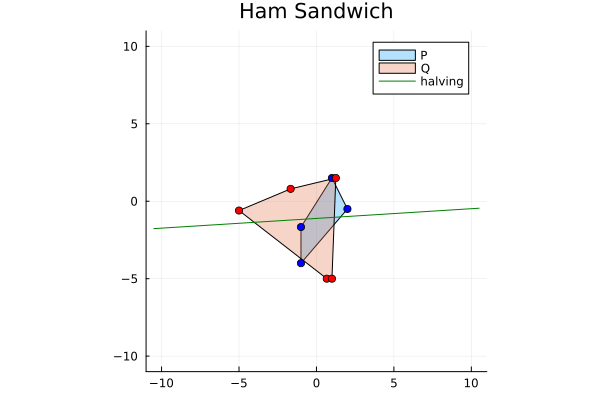

In [131]:
function main()
    n = rand(3:20)
    m = rand(3:20)
    
    rand_frac() = QQ(rand(-5:5)) // QQ(rand(1:5))
    
    V = matrix(QQ, [[rand_frac(), rand_frac()] for i in 1:n])
    W = matrix(QQ, [[rand_frac(), rand_frac()] for i in 1:m])

    println("Points of polygon P =", V)
    println("Points of polygon Q =", W)
    
    P = convex_hull(QQ,V)
    Q = convex_hull(QQ,W)
#    println(ham_sandwich(P,Q))

    P1 = plot_polygon(V)
    P2 = plot_polygon(W)


    fig = plot(P1.x, P1.y, seriestype=:shape, fillalpha=0.3, label="P", aspect_ratio=:equal, title="Ham Sandwich", xlims=(-11,11), ylims=(-11,11))
    plot!(fig, P2.x, P2.y, seriestype=:shape, fillalpha=0.3, label="Q")

    for sol in ham_sandwich(P,Q)
        plot_hyperplane(fig,sol)
    end
    
    scatter!(fig, P1.x, P1.y, color=:blue, label="")
    scatter!(fig, P2.x, P2.y, color=:red, label="")    
end

main()

Tracking 8 paths... 100%|████████████████████████████████████████| Time: 0:00:08
                   # paths tracked: 8
   # non-singular solutions (real): 8 (4)
       # singular endpoints (real): 0 (0)
          # total solutions (real): 8 (4)
Ham sandwich solutions: Any[[0.017170268534578387, 0.9998525800729078, -0.4863443265408602]]

Solution 1: a=5372891//312918286, b=229019392//229053159, c=-67944009//139703509
  Area cut of P = 4.648214285714285 (target = 2603//560 ≈ 4.648214285714285)
  Area cut of Q = 12.725694444444445 (target = 3665//288 ≈ 12.725694444444445)


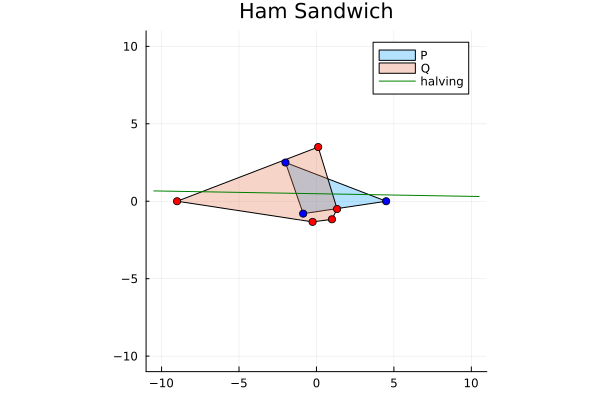

In [24]:
function main()
    n = rand(2:20)
    m = rand(2:20)
    
    rand_frac() = QQ(rand(-10:10)) // QQ(rand(1:10))
    
    V = [[rand_frac(), rand_frac()] for i in 1:n]
    W = [[rand_frac(), rand_frac()] for i in 1:m]

    println("Points of polygon P = ", V)
    println("Points of polygon Q = ", W)
    
    P = convex_hull(QQ, V)
    Q = convex_hull(QQ, W)

    area_P = areaofpolytope(V)
    area_Q = areaofpolytope(W)
    println("Area of P = ", area_P, " ≈ ", Float64(area_P))
    println("Area of Q = ", area_Q, " ≈ ", Float64(area_Q))
    println("Half area of P = ", area_P // 2, " ≈ ", Float64(area_P // 2))
    println("Half area of Q = ", area_Q // 2," ≈ ", Float64(area_Q // 2))

    solutions = ham_sandwich(P, Q)
    println("Ham sandwich solutions: ", solutions)

    for (i, sol) in enumerate(solutions)
        a0 = QQ(rationalize(sol[1]))
        b0 = QQ(rationalize(sol[2]))
        c0 = QQ(rationalize(sol[3]))
        cut_P = positive_areaofcut(V, a0, b0, c0)
        cut_Q = positive_areaofcut(W, a0, b0, c0)
        println("\nSolution $i: a=$a0, b=$b0, c=$c0")
        println("  Area cut of P = ", Float64(cut_P), " (target = ", area_P//2," ≈ ",  Float64(area_P//2),")")
        println("  Area cut of Q = ", Float64(cut_Q), " (target = ", area_Q//2," ≈ ",  Float64(area_Q//2),")")
    end

    # plot
    V_mat = matrix(QQ, V)
    W_mat = matrix(QQ, W)
    P1 = plot_polygon(V_mat)
    P2 = plot_polygon(W_mat)
    
    fig = plot(P1.x, P1.y, seriestype=:shape, fillalpha=0.3, label="P", aspect_ratio=:equal, title="Ham Sandwich", xlims=(-11,11), ylims=(-11,11))
    plot!(P2.x, P2.y, seriestype=:shape, fillalpha=0.3, label="Q")

    for sol in ham_sandwich(P,Q)
        plot_hyperplane(fig,sol)
    end
    
    scatter!(fig, P1.x, P1.y, color=:blue, label="")
    scatter!(fig, P2.x, P2.y, color=:red, label="")
    display(fig)
end

main()

In [35]:
function main()
    V = [
        [QQ(4), QQ(1)],
        [QQ(5), QQ(3)],
        [QQ(2), QQ(4)],
        [QQ(0), QQ(2)],
        [QQ(1), QQ(1)]
    ]

    W = [[QQ(0), QQ(1)],
        [QQ(1), QQ(0)],
        [QQ(1), QQ(1)]]
    P = convex_hull(QQ,V)
    Q = convex_hull(QQ,W)

    println(ham_sandwich(P,Q))
end
main()

Any[[-0.6602219467470534, 0.7510705566280248, -0.06778225862365692], [-0.0, -1.0000000000000004, 0.999999999940594], [0.6602219467470534, -0.7510705566280249, 0.06778225862365692]]
